<a href="https://colab.research.google.com/github/niruinso/Course_Work/blob/develop/src/LinearModels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import warnings
import numpy as np

warnings.filterwarnings('ignore')
np.random.seed(42)

## Линейные модели. Суть линейных моделей состоит в том, чтобы использовать линейную функцию для аппроксимации распределения данных. Линейные модели подбирают коэффициенты для линейной функции таким образом, чтобы средняя квадратическая ошибка (MSE) была минимальной:

\begin{equation*}
MSE = \frac{1}{m}\sum_{i=1}^{m}(y\_pred^{(i)}-y^{(i)})^2
\end{equation*}

## Последнее равенство записано в векторном виде, причем к признакам добавлен новый столбец с индексом 0, который всегда равен единице для любого объекта. Имеем:

\begin{equation*}
 \frac{\partial}{\partial \theta_j}MSE(\theta) = \frac{2}{m}\sum_{i=1}^{m}(\theta^Tx^{(i)}-y^{(i)})x_j^{(i)}
\end{equation*}

## Вычислим все производные сразу в векторной форме, получим:

\begin{equation*}
\bigtriangledown_{\theta}MSE(\theta)= \frac{2}{m}X^T(X\cdot\theta-y)
\end{equation*}

## Найденное выражение можно использовать для метода градиентного спуска и нахождения точки глобального минимума функции издержек (является выпуклой, значит, точка существует). Однако давайте приведем еще и аналитическое решение путем выражения θ. Для этого воспользуемся тем фактом, что в точке, в котором производная равна нулю, функция достигает экстремального значения, а с условием того, что функция выпукла, мы получим точку минимума:

\begin{equation*}
\frac{2}{m}X^T(X\cdot\theta-y)=0\rightarrow\theta=(X^TX)^{-1}X^Ty
\end{equation*}

## Вот и все. Давайте напишем небольшой класс, реализующий все наши вычисления (для градиентного спуска реализуем своего рода пакетный градиентный спуск для небольшой оптимизации. Если batch_size=1, то получим стохастический градиентный спуск. Оптимизация получается засчет того, что каждая итерация градиентного спуска происходит на небольшом наборе данных, засчет чего программа работает быстрее).
## Небольшая выноска: метод градиентного спуска предполагает, что мы можем двигаться в направлении антиградиента для нахождения точки минимума некоторой выпуклой функции (при решении задачи безусловной минимизации).

In [2]:
class MyLinearRegression:
    def __init__(self, method='sgd', learning_rate=0.001, n_iter=1000, batch_size=1, random_state=42):
        self.method = method
        self.learning_rate = learning_rate
        self.n_iter = n_iter
        self.batch_size = batch_size
        np.random.seed(random_state)
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape

        self.weights = np.random.randn(n_features)
        self.bias = 0

        if self.method == 'analytical':
            X_bias = np.c_[np.ones(n_samples), X]
            theta = np.linalg.inv(X_bias.T.dot(X_bias)).dot(X_bias.T).dot(y)
            self.bias = theta[0]
            self.weights = theta[1:]

        elif self.method == 'sgd':
            if hasattr(X, 'values'):
                X = X.values
            if hasattr(y, 'values'):
                y = y.values

            n_samples, n_features = X.shape

            self.weights = np.random.randn(n_features)
            self.bias = np.random.randn()

            for _ in range(self.n_iter):
                indices = np.random.permutation(n_samples)
                X_shuffled = X[indices]
                y_shuffled = y[indices]

                for i in range(0, n_samples, self.batch_size):
                    X_batch = X_shuffled[i:i+self.batch_size]
                    y_batch = y_shuffled[i:i+self.batch_size]
                    batch_size = len(y_batch)

                    y_pred = np.dot(X_batch, self.weights) + self.bias

                    dw = (1/batch_size) * np.dot(X_batch.T, (y_pred - y_batch))
                    db = (1/batch_size) * np.sum(y_pred - y_batch)

                    dw = np.clip(dw, -1e3, 1e3)
                    db = np.clip(db, -1e3, 1e3)

                    new_weights = self.weights - self.learning_rate * dw
                    new_bias = self.bias - self.learning_rate * db

                    if np.isfinite(new_weights).all() and np.isfinite(new_bias):
                        self.weights = new_weights
                        self.bias = new_bias
                    else:
                        break
        else:
            raise ValueError("Method must be 'analytical', or 'sgd'")

    def predict(self, X):
        if self.weights is None or self.bias is None:
            raise Exception("Model has not been fitted yet.")
        return np.dot(X, self.weights) + self.bias

## Создадим простой датасет в виде линейной функции с некоторым шумом: y=3x+5+(шум)

In [3]:
X = np.random.rand(100, 1)
y = 3 * X + 5 + np.random.randn(100, 1)

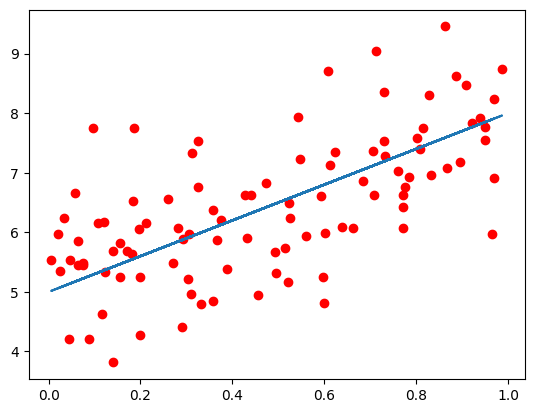

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.plot(X, y, 'o', color='red')
plt.plot(X, 3*X+5)

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
my_linreg = MyLinearRegression()
my_linreg.fit(X_train, y_train)

## Сравним с аналогичным классом из библиотеки sklearn

In [7]:
from sklearn.linear_model import SGDRegressor
SkLearn_linreg = SGDRegressor(penalty=None, tol=0.001, max_iter=1000, random_state=42)
SkLearn_linreg.fit(X_train, y_train)

SGDRegressor(penalty=None, random_state=42)

## Сравниваем MAE, RMSE, r2_score

In [8]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

def show_comparison(my_model, sklearn_model, types_of_comparing):
    print(types_of_comparing)
    my_model_prediction = my_model.predict(X_test)
    sklearn_model_prediction = sklearn_model.predict(X_test)
    print(f"MAE: My Model: {mean_absolute_error(y_test, my_model_prediction)} vs Sklearn: {mean_absolute_error(y_test, sklearn_model_prediction)}")
    print(f"RMSE: My Model: {root_mean_squared_error(y_test, my_model_prediction)} vs Sklearn: {root_mean_squared_error(y_test, sklearn_model_prediction)}")
    print(f"R-Squared: My Model: {r2_score(y_test, my_model_prediction)} vs Sklearn: {r2_score(y_test, sklearn_model_prediction)}")

In [9]:
show_comparison(my_linreg, SkLearn_linreg, "---Linear Regression Comparison---")

---Linear Regression Comparison---
MAE: My Model: 0.5911391910415549 vs Sklearn: 0.5964837936735323
RMSE: My Model: 0.8083646092965225 vs Sklearn: 0.8179134174907966
R-Squared: My Model: 0.4205320290034913 vs Sklearn: 0.4067612402259665


## Небольшие отклонения, но очень близко

In [10]:
print(f"My model: {my_linreg.weights[0][0]} * x + {my_linreg.bias}")

My model: 2.597388247533848 * x + 5.14391242482278


In [11]:
print(f"Sklearn model: {SkLearn_linreg.coef_[0]} * x + {SkLearn_linreg.intercept_[0]}")

Sklearn model: 2.5712510518321543 * x + 5.121336253093001


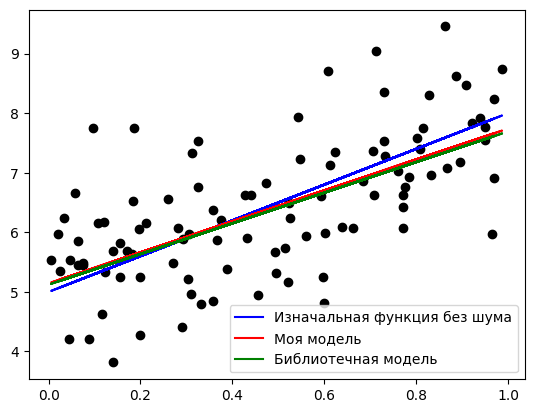

In [12]:
plt.plot(X, y, 'o', color='black')
plt.plot(X, 3*X+5, color='blue', label="Изначальная функция без шума")
plt.plot(X, my_linreg.weights[0] * X + my_linreg.bias, color='red', label="Моя модель")
plt.plot(X, SkLearn_linreg.coef_[0] * X + SkLearn_linreg.intercept_[0], color='green', label="Библиотечная модель")

plt.legend(loc='best')

plt.show()

## Напишем функцию для оценки предсказаний модели на разном количестве тренировочных данных. Цель: посмотреть, как быстро модель теряет в ошибках предсказаний в зависимости от количества тренировочных данных. К тому же можно будет засчет просмотра кривых обучения на тренировочных и тестовых данных посмотреть, как стоит менять модель (в случае недообучения - усложнять, в случае переобучения - делать более простой).

In [13]:
def plot_learning_curves(model, step_size=1):
    train_errors, test_errors = [], []
    for m in range(1, len(X_train), step_size):
        model.fit(X_train[:m], y_train[:m])
        y_train_pred = model.predict(X_train[:m])
        y_test_pred = model.predict(X_test)
        train_errors.append(root_mean_squared_error(y_train_pred, y_train[:m]))
        test_errors.append(root_mean_squared_error(y_test_pred, y_test))
    plt.plot(train_errors, "r--", linewidth=2, label="train")
    plt.plot(test_errors, "b-", linewidth=3, label="test")
    plt.legend(loc='best')

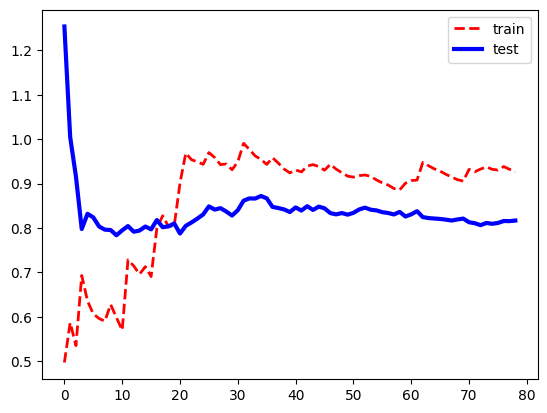

In [14]:
plot_learning_curves(SkLearn_linreg)

## Интересно то, что на малых данных градиентный спуск показывает себя крайне плохо. Это связано с тем, что на малом числе объектов труудно оценить градиент функции издекржек, из-за чего модель получается слишком простой и мы получаем недообучение (модель плохо оценивает и тренировочные, и тестовые данные). Однако видно, что потом все стабилизируется. Более того, мы видим не столь сильное отличие в предсказаниях валидационных и тренировочных данных в конце, что говорит об отсутствии переобучения. В случае переобучения (хорошие предсказания на тренировочных данных и похуже на валидационных) пришлось бы немного упрощать модель засчет регуляризации.

## Регуляризация предполагает навешивание определенных условий на нашу модель. В случае линейной функции предсказаний регуляризация будет пытаться контролировать веса линейной функции. Существуют следующие виды регуляризации:
## 1) Гребневая регрессия (регрессия Тихонова, Ridge, l2 регуляризация) имеет следующий вид функции издержек:

\begin{equation*}
J(\theta) = \frac{1}{m}\sum_{i=1}^{m}(\theta^Tx^{(i)}-y^{(i)})^2 + \alpha\frac{1}{2}\sum_{i=1}^{n}\theta_i^2
\end{equation*}

## Вектор-субградиент:

\begin{equation*}
g(\theta, J) = \frac{2}{m}X^T(X\cdot\theta-y) + \alpha\sum_{i=1}^{n}\theta_i
\end{equation*}

## 2) Лассо (least absolute shrinkage and selection operator) регрессия (регрессия методом наименьшего абсолютного сокращения и выбора, l1 регуляризация).  Имеет следующий вид функции издержек:

\begin{equation*}
J(\theta) = \frac{1}{m}\sum_{i=1}^{m}(\theta^Tx^{(i)}-y^{(i)})^2 + \alpha\sum_{i=1}^{n}|\theta_i|
\end{equation*}

## Вектор-субградиент:

\begin{equation*}
g(\theta, J) = \frac{2}{m}X^T(X\cdot\theta-y) + \alpha\begin{pmatrix}
sign(\theta_1) \\
sign(\theta_2) \\
\vdots \\
sign(\theta_n)
\end{pmatrix}
\end{equation*}

## sign(x) равен 1 для положительных значений аргумента, -1 для отрацельных и 0 для нулевых значений аргумента

## 3) Эластичная сеть (ElasticNet) - комбинация из лассо и гребневой регрессий:

\begin{equation*}
J(\theta) = \frac{1}{m}\sum_{i=1}^{m}(\theta^Tx^{(i)}-y^{(i)})^2 + r\alpha\sum_{i=1}^{n}|\theta_i|+\alpha\frac{1-r}{2}\sum_{i=1}^{n}\theta_i^2
\end{equation*}

## Рассмотрим, как работает гребневая функция.

In [15]:
SkLearn_ridge = SGDRegressor(penalty='l2', alpha=0.01, random_state=42)
SkLearn_ridge.fit(X_train, y_train)

SGDRegressor(alpha=0.01, random_state=42)

In [16]:
root_mean_squared_error(SkLearn_ridge.predict(X_test), y_test)

0.8188844493497932

In [17]:
mean_absolute_error(SkLearn_ridge.predict(X_test), y_test)

0.5913370166912953

In [18]:
SkLearn_linreg.fit(X_train, y_train)

SGDRegressor(penalty=None, random_state=42)

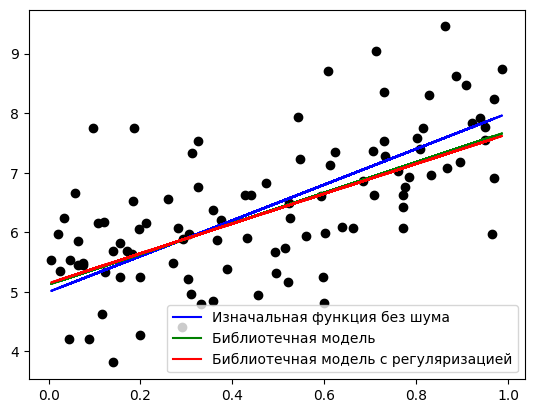

In [19]:
plt.plot(X, y, 'o', color='black')
plt.plot(X, 3*X+5, color='blue', label="Изначальная функция без шума")
plt.plot(X, SkLearn_linreg.coef_[0] * X + SkLearn_linreg.intercept_[0], color='green', label="Библиотечная модель")
plt.plot(X, SkLearn_ridge.coef_[0] * X + SkLearn_ridge.intercept_[0], color='red', label="Библиотечная модель с регуляризацией")

plt.legend(loc='best')

plt.show()

## Чуть увеличим значение α, тем самым сделаем модель более простой (так как веса будут ограничиваться тем сильнее, чем больше коэффициент, и наоборот)

In [20]:
SkLearn_ridge = SGDRegressor(penalty='l2', alpha=2, random_state=42)
SkLearn_ridge.fit(X_train, y_train)

SGDRegressor(alpha=2, random_state=42)

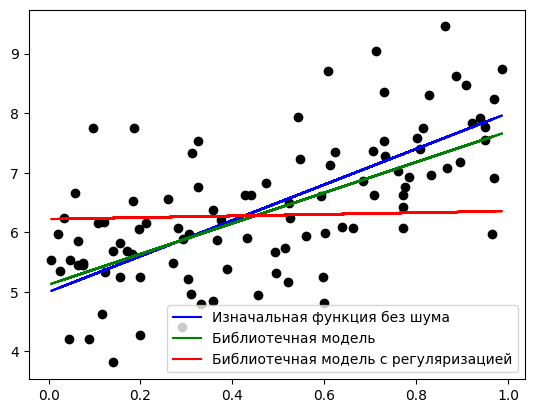

In [21]:
plt.plot(X, y, 'o', color='black')
plt.plot(X, 3*X+5, color='blue', label="Изначальная функция без шума")
plt.plot(X, SkLearn_linreg.coef_[0] * X + SkLearn_linreg.intercept_[0], color='green', label="Библиотечная модель")
plt.plot(X, SkLearn_ridge.coef_[0] * X + SkLearn_ridge.intercept_[0], color='red', label="Библиотечная модель с регуляризацией")

plt.legend(loc='best')

plt.show()

## Веса стали близки к нулю, из-за чего мы получили простую прямую, почти параллельную оси абсцисс. Регуляризация не трогает свободный кэффициент

## Хотелось бы предсказывать не только линейные функции, но и функции более сложного вида. Поэтому давайте рассмотрим один из способов это сделать: использование PolynomialFeatures. На самом деле он работает предельно просто: при передаче натурального параметра в качестве степени полинома добавляются новые признаки, которые появляются путем возведения в степень и перемножения исходных признаков (до степени переданного значения). Основная загвоздка состоит в том, что при больших степенях и при немалом количестве признаков мы сильно увеличим датасет, получим своего рода проклятие размерности (слишком много признаков), ведь при n изначальных признаках и d степенях для PolynomialFeatures мы получаем:

\begin{equation*}
\frac {(n+d)!}{n!d!}
\end{equation*}

## признаков. Но давайте построим задачу предсказания полинома третьей степени при помощи этого приема:

\begin{equation*}
y = 3x^3 + 2x^2+7x+1
\end{equation*}

In [22]:
X = np.random.uniform(-5, 5, 100)
X = X.reshape(-1, 1)
y = 3 * X**3 - 2*X**2 - 7*X + 1 + np.random.uniform(-10, 10, 100).reshape(-1,1)

In [23]:
X_smooth = np.linspace(-5, 5, 500).reshape(-1, 1)
y_vals = 3*X_smooth*X_smooth*X_smooth - 2*X_smooth*X_smooth - 7*X_smooth + 1

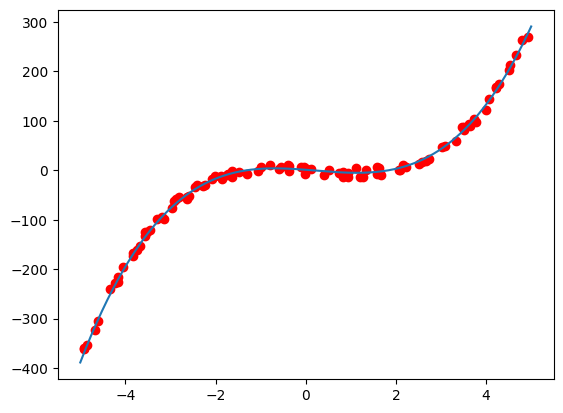

In [24]:
plt.plot(X, y, 'o', color='red')
plt.plot(X_smooth, y_vals)

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Не забудем нормализовать данные, чтобы более высокие степени не выделялись на основе менее маленьких (ибо третья степень может очень сильно повлиять на разброс данных в наборе данных)

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression

SkLearn_linreg = Pipeline([
    ('poly', PolynomialFeatures(degree=3)),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
SkLearn_linreg.fit(X_train, y_train)

Pipeline(steps=[('poly', PolynomialFeatures(degree=3)),
                ('scaler', StandardScaler()), ('model', LinearRegression())])

In [27]:
y_pred = SkLearn_linreg.predict(X_test)
print(f"MAE: {mean_absolute_error(y_pred, y_test)}, RMSE: {root_mean_squared_error(y_pred, y_test)}")

MAE: 5.463747309340697, RMSE: 6.236864252208502


## Посмотрим на графике

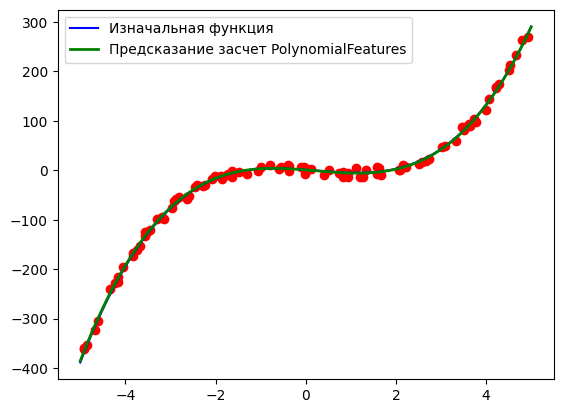

In [28]:
plt.plot(X, y, 'o', color='red')
plt.plot(X_smooth, y_vals, color='blue', label='Изначальная функция')
plt.plot(X_smooth, SkLearn_linreg.predict(X_smooth), color='green', linewidth=2, label='Предсказание засчет PolynomialFeatures')
plt.legend(loc='best')

## Они словно слились воедино

## Теперь, когда некоторая теория уже есть, вернемся к нашей задаче: предсказание предполагаемого результата за экзамен. Давайте загрузим тренировочные и валидационные данные, созданные ранее при помощи Preprocessing.ipynb

In [29]:
import pandas as pd

train_df = pd.read_csv("data/Train.csv")
valid_df = pd.read_csv("data/Valid.csv")

In [30]:
X_train = train_df.drop('Exam_Score', axis=1)
X_valid = valid_df.drop('Exam_Score', axis=1)

y_train = train_df['Exam_Score']
y_valid= valid_df['Exam_Score']

## Опробуем несколько линейных моделей: с регуляризацией и без, а также попробуем поиграться со степенями полиномов. Другими словами, попытаемся подобрать наилучше гиперпараметры. Для этого воспользуемся GridSearch - поиском по сетке, который скоро создадим

## Вообще говоря, у линейной регрессии как таковой не так уж и много параметров, особенно тех, которые можно подбирать. Поэтому давайте объединим эту модель с полиномами разных степеней

## Все же, думаю, стоит показать, как работает GridSearchCV. Во-первых, это обычный поиск по сетке, ничего более. Мы просто берем словарь параметров, а потом эти параметры подставляются в модель, для которой подбираются гиперпараметры. Выбираются все возможное комбинации значений из каждого ключа. CV - Cross-Validation. Кросс валидация предполагает разбиение данных на несколько чайстей с последующим обучением и предсказанием. При кросс валидации модель получает разные тренировочные и тестовые данные, а в качестве метрики оценивания выступает среднее ошибок. На самом деле, кросс валидация предпочтительнее обычного предсказывания на одном делении данных, так как меньше вероятность, что модель покажет себя хорошо только из-за хорошего разделения данных. К примеру, разберем KFold() - один из самых простых способов перекрестной валидации. Его суть состоит в том, что данные делятся на некоторое число n равных частей. На каждом этапе одна часть выступает в качестве тестовой, а остальные данные - в качестве тренировочных. В нашем случае количество групп разделения определяется через параметр cv
## Значение verbose внутри gridsearch контролирует отправку сообщений о текущем состоянии оптимизации (можно использовать n_jobs=-1 для использования всех ядер для ускорения процесса оптимизации, но тогда сообщения о текущем состоянии не высвечиваются)

In [31]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

## Отметим, что не имеет смысла использовать PolynomialFeatures без регуляризации. Причина проста: высокие степени предполагают большое число признаков, которые выступают в виде степеней полинома. Чем больше степень, тем сильнее модель будет переобучаться. Другими словами, если не использовать регуляризацию с PolynomialFeatures, мы получим высокие веса нашей модели, она будет пытаться подогнать функцию предсказаний под все точки, из-за чего станет довольно плохой. Вот пример:

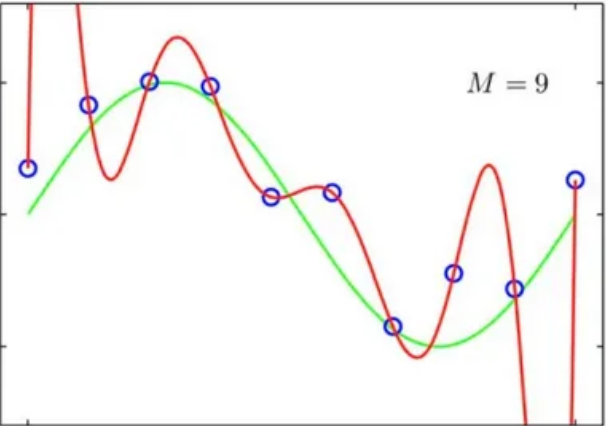

In [32]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import SGDRegressor

polynomial_params = {
    'poly__degree': [1, 2, 3, 4, 5]
}

poly_model = Pipeline([
    ('poly', PolynomialFeatures()),
    ('model', Ridge(random_state=42))
])

grid_search = GridSearchCV(poly_model, polynomial_params, scoring='neg_root_mean_squared_error', cv=3, verbose=10)
grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

best_poly_reg = grid_search.best_estimator_

Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV 1/3; 1/5] START poly__degree=1..............................................
[CV 1/3; 1/5] END ..............poly__degree=1;, score=-1.173 total time=   0.0s
[CV 2/3; 1/5] START poly__degree=1..............................................
[CV 2/3; 1/5] END ..............poly__degree=1;, score=-2.548 total time=   0.0s
[CV 3/3; 1/5] START poly__degree=1..............................................
[CV 3/3; 1/5] END ..............poly__degree=1;, score=-2.276 total time=   0.0s
[CV 1/3; 2/5] START poly__degree=2..............................................
[CV 1/3; 2/5] END ..............poly__degree=2;, score=-1.347 total time=   0.1s
[CV 2/3; 2/5] START poly__degree=2..............................................
[CV 2/3; 2/5] END ..............poly__degree=2;, score=-2.606 total time=   0.2s
[CV 3/3; 2/5] START poly__degree=2..............................................
[CV 3/3; 2/5] END ..............poly__degree=2;, 

## Рассмотрим гребневую регуляризацию

## Стоит отметить, что при значении гиперпараметра alpha, раным нулю, мы получаем обычную регрессионную модель без регуляризации (можно проверить простой подстановкой в формулу)

In [33]:
ridge_model = Ridge()

ridge_params = {
    'alpha': [0, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'fit_intercept': [True, False],
    'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga']
}

grid_search = GridSearchCV(ridge_model, ridge_params, cv=3, verbose=5)
grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

best_ridge_model = grid_search.best_estimator_

Fitting 3 folds for each of 98 candidates, totalling 294 fits
[CV 1/3] END alpha=0, fit_intercept=True, solver=auto;, score=0.889 total time=   0.0s
[CV 2/3] END alpha=0, fit_intercept=True, solver=auto;, score=0.617 total time=   0.0s
[CV 3/3] END alpha=0, fit_intercept=True, solver=auto;, score=0.678 total time=   0.0s
[CV 1/3] END alpha=0, fit_intercept=True, solver=svd;, score=0.889 total time=   0.0s
[CV 2/3] END alpha=0, fit_intercept=True, solver=svd;, score=0.617 total time=   0.0s
[CV 3/3] END alpha=0, fit_intercept=True, solver=svd;, score=0.678 total time=   0.0s
[CV 1/3] END alpha=0, fit_intercept=True, solver=cholesky;, score=0.889 total time=   0.0s
[CV 2/3] END alpha=0, fit_intercept=True, solver=cholesky;, score=0.617 total time=   0.0s
[CV 3/3] END alpha=0, fit_intercept=True, solver=cholesky;, score=0.678 total time=   0.0s
[CV 1/3] END alpha=0, fit_intercept=True, solver=lsqr;, score=0.891 total time=   0.0s
[CV 2/3] END alpha=0, fit_intercept=True, solver=lsqr;, sco

## Рассмотрим lasso-регуляризацию

In [34]:
lasso_model = Lasso()

lasso_params = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
    'fit_intercept': [True, False],
    'max_iter': [1000, 5000, 10000],
    'tol': [0.0001, 0.001, 0.01],
    'selection': ['cyclic', 'random']
}

grid_search = GridSearchCV(lasso_model, lasso_params, cv=3, verbose=5)
grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

best_lasso_model = grid_search.best_estimator_

Fitting 3 folds for each of 180 candidates, totalling 540 fits
[CV 1/3] END alpha=0.001, fit_intercept=True, max_iter=1000, selection=cyclic, tol=0.0001;, score=0.891 total time=   0.0s
[CV 2/3] END alpha=0.001, fit_intercept=True, max_iter=1000, selection=cyclic, tol=0.0001;, score=0.619 total time=   0.0s
[CV 3/3] END alpha=0.001, fit_intercept=True, max_iter=1000, selection=cyclic, tol=0.0001;, score=0.678 total time=   0.0s
[CV 1/3] END alpha=0.001, fit_intercept=True, max_iter=1000, selection=cyclic, tol=0.001;, score=0.891 total time=   0.0s
[CV 2/3] END alpha=0.001, fit_intercept=True, max_iter=1000, selection=cyclic, tol=0.001;, score=0.619 total time=   0.0s
[CV 3/3] END alpha=0.001, fit_intercept=True, max_iter=1000, selection=cyclic, tol=0.001;, score=0.678 total time=   0.0s
[CV 1/3] END alpha=0.001, fit_intercept=True, max_iter=1000, selection=cyclic, tol=0.01;, score=0.891 total time=   0.0s
[CV 2/3] END alpha=0.001, fit_intercept=True, max_iter=1000, selection=cyclic, to

## Рассмотрим эластичную сеть

In [35]:
net_model = ElasticNet()

net_params = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
    'l1_ratio': [0.1, 0.5, 0.7, 0.9, 1.0],
    'fit_intercept': [True, False],
    'max_iter': [1000, 5000, 10000],
    'tol': [0.0001, 0.001, 0.01],
    'selection': ['cyclic', 'random']
}

grid_search = GridSearchCV(net_model, net_params, cv=3, verbose=5)
grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

best_net_model = grid_search.best_estimator_

Fitting 3 folds for each of 900 candidates, totalling 2700 fits
[CV 1/3] END alpha=0.001, fit_intercept=True, l1_ratio=0.1, max_iter=1000, selection=cyclic, tol=0.0001;, score=0.891 total time=   0.1s
[CV 2/3] END alpha=0.001, fit_intercept=True, l1_ratio=0.1, max_iter=1000, selection=cyclic, tol=0.0001;, score=0.619 total time=   0.0s
[CV 3/3] END alpha=0.001, fit_intercept=True, l1_ratio=0.1, max_iter=1000, selection=cyclic, tol=0.0001;, score=0.678 total time=   0.0s
[CV 1/3] END alpha=0.001, fit_intercept=True, l1_ratio=0.1, max_iter=1000, selection=cyclic, tol=0.001;, score=0.891 total time=   0.0s
[CV 2/3] END alpha=0.001, fit_intercept=True, l1_ratio=0.1, max_iter=1000, selection=cyclic, tol=0.001;, score=0.619 total time=   0.0s
[CV 3/3] END alpha=0.001, fit_intercept=True, l1_ratio=0.1, max_iter=1000, selection=cyclic, tol=0.001;, score=0.678 total time=   0.0s
[CV 1/3] END alpha=0.001, fit_intercept=True, l1_ratio=0.1, max_iter=1000, selection=cyclic, tol=0.01;, score=0.891 t

## Итак, у нас есть несколько линейных моделей. Давайте рассмотрим их точность на валидационных данных

In [36]:
def show_scores(model, model_name):
    y_pred = model.predict(X_valid)
    print(f"Scoring of {model_name} Model")
    print(f"RMSE: {root_mean_squared_error(y_valid, y_pred)}")
    print(f"MAE: {mean_absolute_error(y_valid, y_pred)}")
    print(f"R2: {r2_score(y_valid, y_pred)}\n")

In [37]:
show_scores(best_poly_reg, "Poly Model")
show_scores(best_ridge_model, "Ridge Model")
show_scores(best_lasso_model, "Lasso Model")
show_scores(best_net_model, "ElasticNet Model")

Scoring of Poly Model Model
RMSE: 2.2698365630953976
MAE: 0.506702557084115
R2: 0.6740134656408343

Scoring of Ridge Model Model
RMSE: 2.2698492806493236
MAE: 0.5066805780721766
R2: 0.6740098127232531

Scoring of Lasso Model Model
RMSE: 2.269753815780866
MAE: 0.5067579829348381
R2: 0.6740372330072164

Scoring of ElasticNet Model Model
RMSE: 2.2698232646937817
MAE: 0.506891652620966
R2: 0.6740172853758996



## Рассмотрим обучаемость наших моделей

In [48]:
def plot_learning_curves(model, step_size=1):
    train_errors, valid_errors = [], []
    for m in range(1, len(X_train), step_size):
        model.fit(X_train[:m], y_train[:m])
        y_train_pred = model.predict(X_train[:m])
        y_valid_pred = model.predict(X_valid)
        train_errors.append(root_mean_squared_error(y_train_pred, y_train[:m]))
        valid_errors.append(root_mean_squared_error(y_valid_pred, y_valid))
    plt.plot(train_errors, "r--", linewidth=2, label="train")
    plt.plot(valid_errors, "b-", linewidth=3, label="valid")
    plt.legend(loc='best')

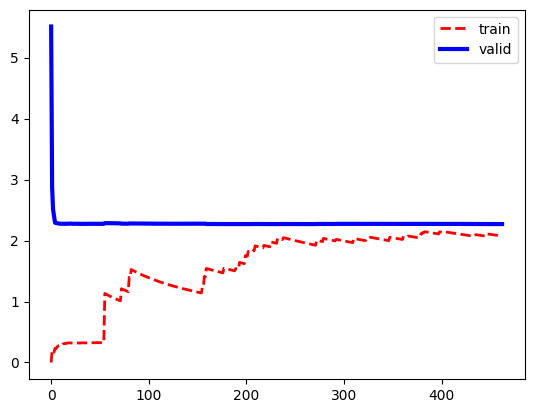

In [49]:
plot_learning_curves(best_poly_reg, step_size=10)

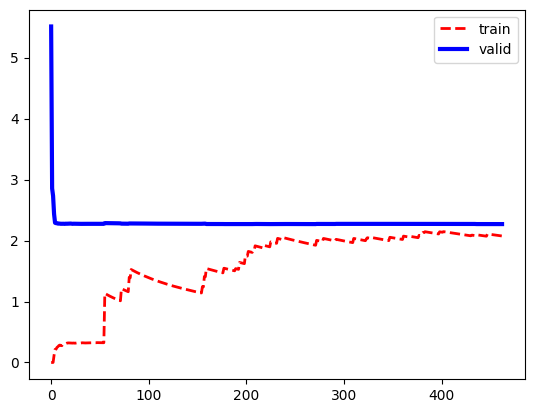

In [50]:
plot_learning_curves(best_ridge_model, step_size=10)

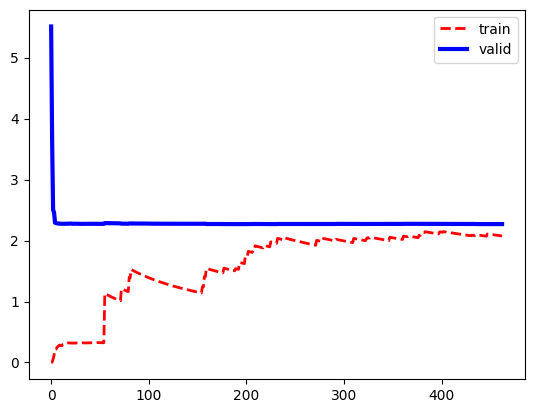

In [51]:
plot_learning_curves(best_lasso_model, step_size=10)

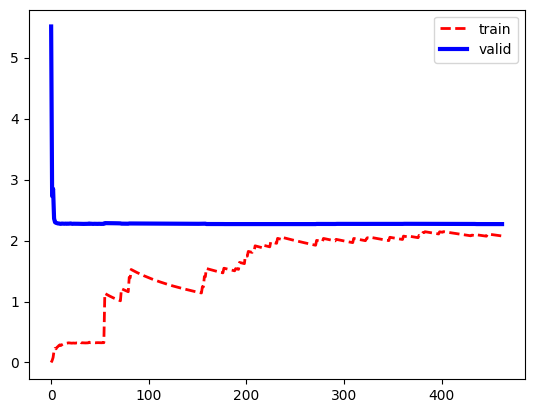

In [52]:
plot_learning_curves(best_net_model, step_size=10)

## Видно, что наши модели обучаются примерно одинаково в зависимости от объема тренировочных данных. В конце корень среднеквадратической ошибки при предсказании тренировочных и валидационных данных приходит в некое равновесие, переобучение или недообучение не наблюдаются

## И давайте посмотрим на график отклонения предсказаний

In [81]:
def vizual_pred_test(y_test, y_pred, title):
    plt.figure(figsize=(10, 10))

    plt.scatter(y_test, y_pred, alpha=0.3, s=10, c='blue', label='Предсказания')

    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Идеальное предсказание')

    plt.xlabel('Тестовые данные', fontsize=12)
    plt.ylabel('Предсказанные точки', fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis('equal')

    plt.tight_layout()
    plt.show()

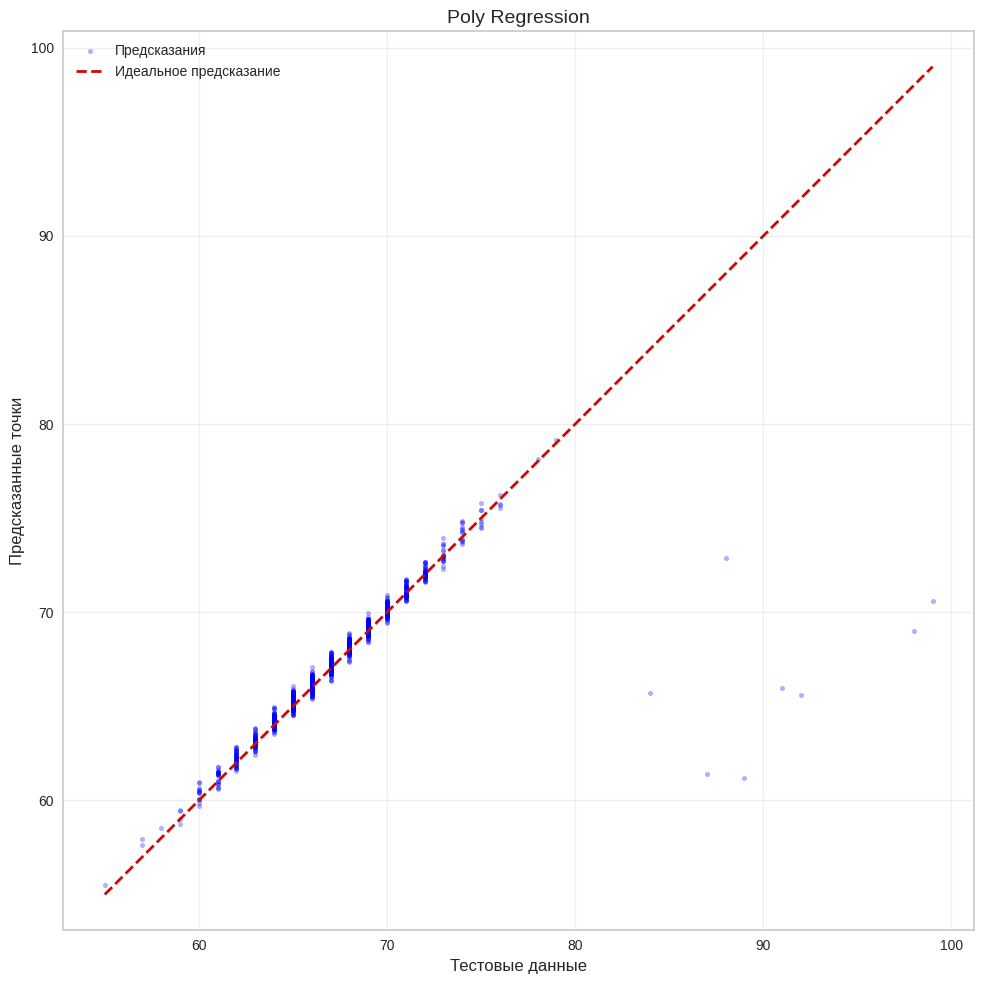

In [82]:
vizual_pred_test(y_valid, best_poly_reg.predict(X_valid), "Poly Regression")

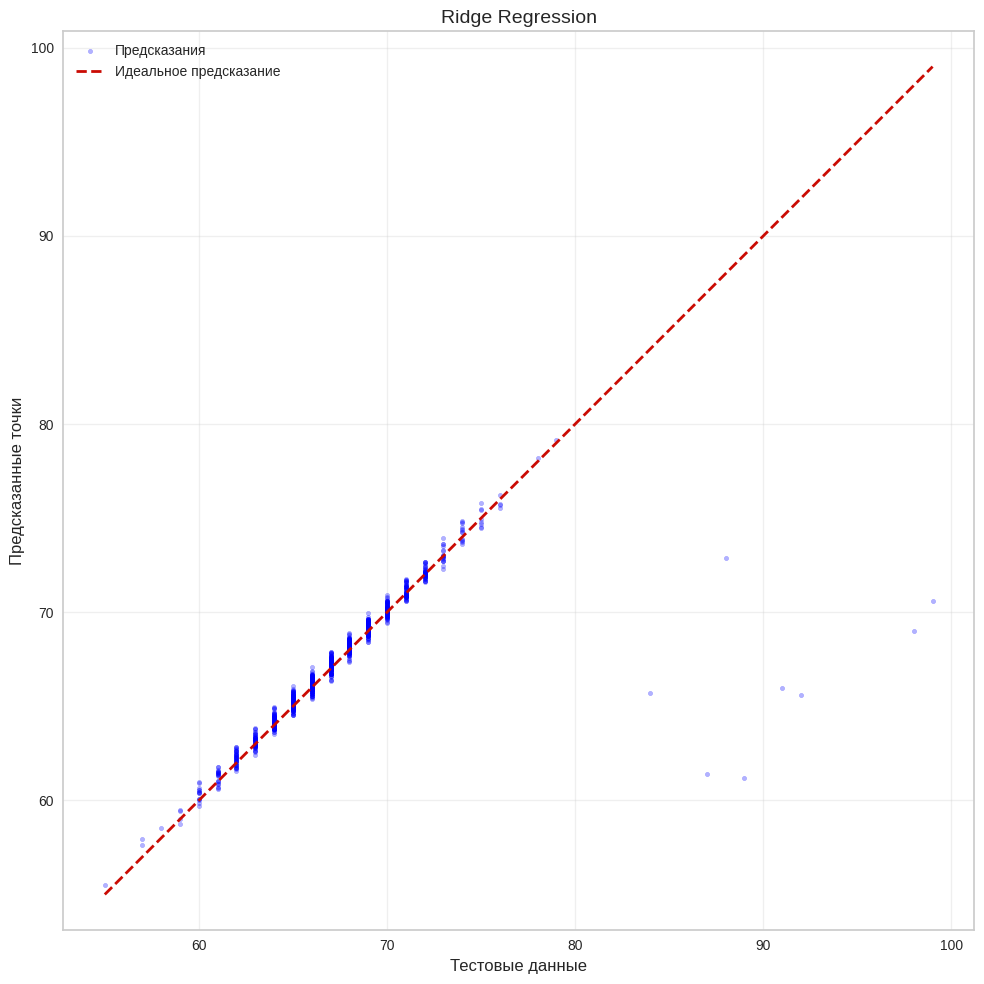

In [83]:
vizual_pred_test(y_valid, best_ridge_model.predict(X_valid), "Ridge Regression")

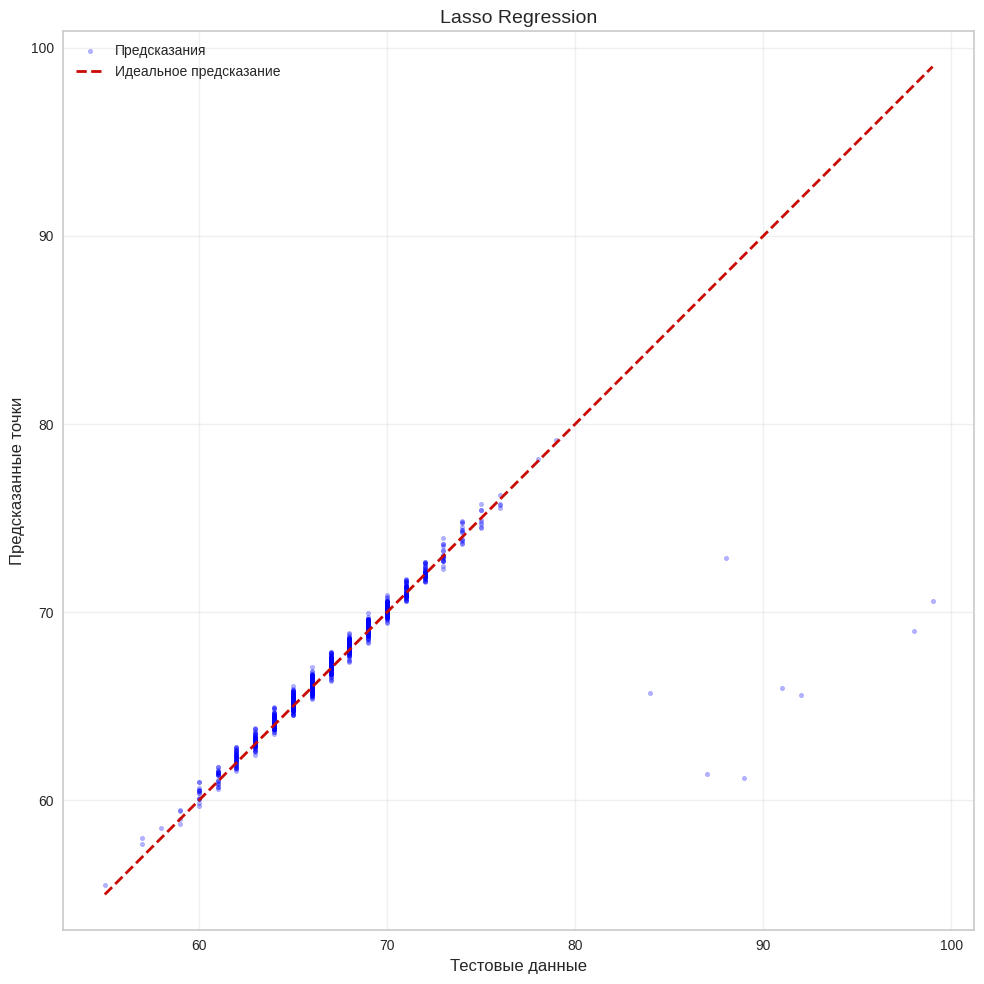

In [84]:
vizual_pred_test(y_valid, best_lasso_model.predict(X_valid), "Lasso Regression")

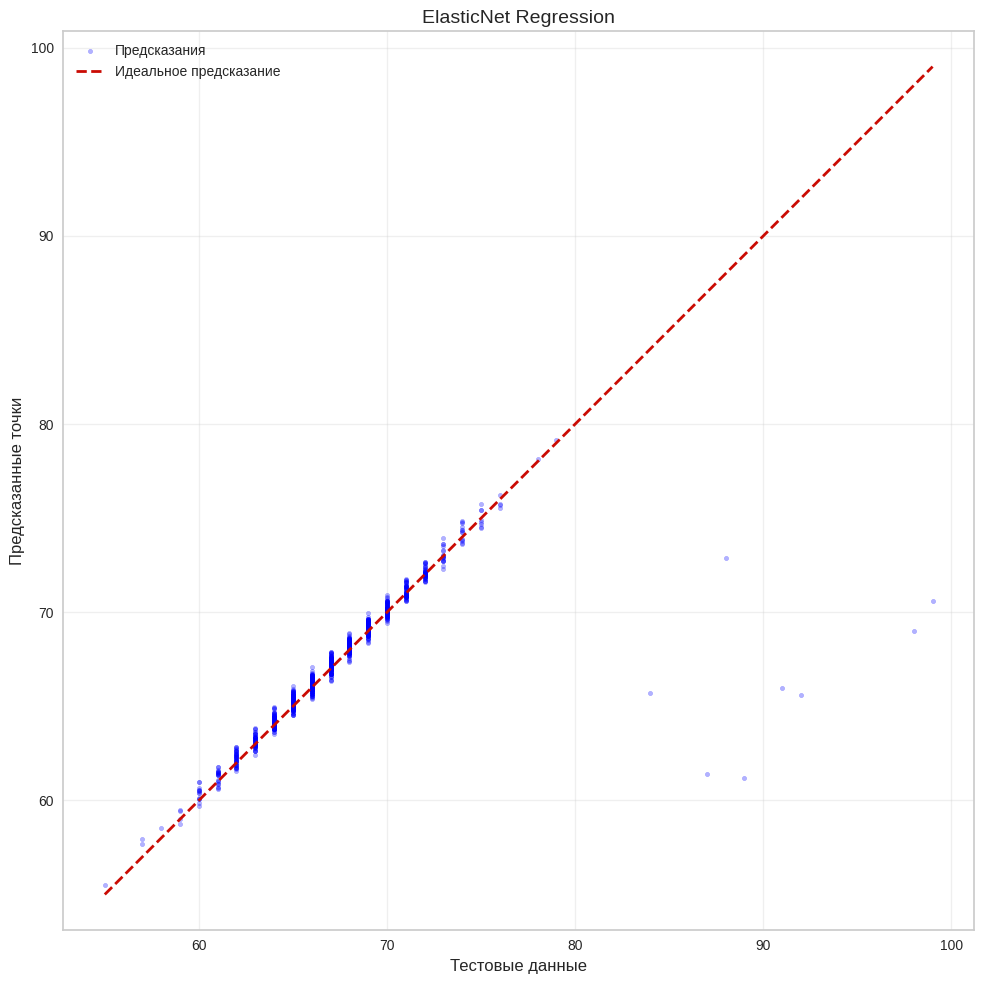

In [85]:
vizual_pred_test(y_valid, best_net_model.predict(X_valid), "ElasticNet Regression")

## Видно, что в целом предсказания очень хорошие, за исключением десятки точек на значениях, больших 85

## Давайте сохраним эти результаты

In [53]:
results_linear_models = pd.DataFrame(columns=['model', 'MAE', 'RMSE', 'R2'])

In [54]:
def resulting(model, df, model_name):
    prediction = model.predict(df)
    row = {'model': model_name,
                  'params': model.get_params(),
                  'MAE': mean_absolute_error(y_valid, prediction),
                  'RMSE': root_mean_squared_error(y_valid, prediction),
                  'R2': r2_score(y_valid, prediction)}
    results_linear_models.loc[len(results_linear_models)] = row

In [55]:
resulting(best_poly_reg, X_valid, "Poly Linear Regression")
resulting(best_ridge_model, X_valid, "Ridge")
resulting(best_lasso_model, X_valid, "Lasso")
resulting(best_net_model, X_valid, "ElasticNet")

In [56]:
results_linear_models

,model,MAE,RMSE,R2
0,Poly Linear Regression,0.506658,2.269837,0.674013
1,Ridge,0.506636,2.269850,0.674010
2,Lasso,0.506741,2.269717,0.674048
3,ElasticNet,0.506713,2.269774,0.674032


In [57]:
results_linear_models.to_csv("data/result_linear.csv")